In [47]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KernelDensity as KD
from sklearn.kernel_ridge import KernelRidge as KR
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.metrics import accuracy_score, roc_auc_score,confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from folktables import ACSDataSource, ACSEmployment, ACSIncome, ACSPublicCoverage, ACSMobility
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
import sys
sys.path.append('Level-Set-Boosting')
from sklearn.decomposition import PCA
from utils import grid_search_params
from MCBoost import MCBoost
from MAccWitness import MAccWitness
from matplotlib.colors import ListedColormap
from sklearn import datasets

In [109]:

def lightweight_calibration_with_witness(features,label, baseline_model, witness_metric):
  scaler = StandardScaler()
  #fit transform data
  features = scaler.fit_transform(features, label)
  label = label.astype('int')
  # label = np.intc(label)

  X_train_val, X_test, y_train_val, y_test = train_test_split(
      features, label, test_size=0.5, random_state=0)

  X_train, X_val, y_train, y_val = train_test_split(
      X_train_val, y_train_val, test_size=0.5, random_state=0)

  X_wit, X_test, y_wit, y_test = train_test_split(
      X_test, y_test, test_size=0.5, random_state=0)
  
  # baseline classifier
  if baseline_model == "Logistic_Regression":
      model = LogisticRegression()
  elif baseline_model == "Decision_Tree":
      model = DecisionTreeClassifier(max_depth = 1)
  elif baseline_model == "Random_Forest":
      model = RandomForestClassifier(max_depth=2, random_state=0)
  elif baseline_model == "Kernel_SVM":
      model = SVC(gamma="auto", probability = True)
  elif baseline_model == "Naive_Bayes":
      model = GaussianNB()
  elif baseline_model == "NN":
      model = MLPClassifier(random_state=1, max_iter=300)
  else:
    return "Baseline not supported"
  #model = make_pipeline(StandardScaler(), LogisticRegression())
  model.fit(X_train, y_train)

  yhat = model.predict(X_test)
  if baseline_model == "Logistic_Regression":
    yhat_prob = model.predict_proba(X_test)
    # choose the probability of the positive class
    yhat_prob = yhat_prob[:, 1]
  else:
    yhat_prob = model.predict(X_test)

  # evaluate the accuracy of the model
  accuracy = accuracy_score(y_test, yhat>0.5)
  # , multi_class = 'ovr'
  auc = roc_auc_score(y_test, yhat_prob)
  print(f'{baseline_model} Baseline Model Performance')
  print('Accuracy: %.2f' % (accuracy*100))
  print('AUC: %.2f' % (auc*100))

  if baseline_model == "Logistic_Regression":
    yhat_proba_test = model.predict_proba(X_test)[:, 1]
    yhat_proba_wit = model.predict_proba(X_wit)[:, 1]
    yhat_proba_val = model.predict_proba(X_val)[:, 1]
  else:
    yhat_proba_test = model.predict(X_test)
    yhat_proba_wit = model.predict(X_wit)
    yhat_proba_val = model.predict(X_val)


  error_test = y_test - yhat_proba_test
  error_wit = y_wit - yhat_proba_wit
  error_val = y_val - yhat_proba_val


  yhat_wit = (yhat_proba_wit>=0.5).astype(int)
  yhat_test = (yhat_proba_test>=0.5).astype(int)
  # search for optimal rbf kernel param using validation set
  # witness_metric = 'rbf'

  # dimensionality reduction for dim>5
  if X_wit.shape[1] > 10:
    print('Dimensionality reduction using PCA')
    pca = PCA(n_components=10)
    X_wit = pca.fit_transform(X_wit)
    X_test = pca.transform(X_test)
    X_val = pca.transform(X_val)
    
  gopt = grid_search_params(witness_metric, X_val, error_val)

  # define witness on train and validation
  wit = MAccWitness(gamma=gopt, metric=witness_metric)

  wit_model = make_pipeline(StandardScaler(), wit)
  # fit 0-1 error to witness function
  error_wit = (y_wit != yhat_wit).astype(int)
  wit_model.fit(X_wit, error_wit)

  wit_val = wit_model.predict(X_wit)
  wit_test = wit_model.predict(X_test)


  return wit_val, wit_test, y_wit, y_test, yhat_wit, yhat_test, yhat_proba_wit, yhat_proba_test

In [110]:
import heapq

def top_k_indices(lst, k):
    """
    Returns the indices of the top k elements in the list.
    """
    return heapq.nlargest(k, range(len(lst)), lst.__getitem__)

def top_k_samples(wit_values, k, correct_labels, predicted_labels, show_imgs=False):
    """
    Prints the values in listA that correspond to the top k highest values in listB.
    """
    top_indices = top_k_indices(wit_values, k)
    count_error = 0
    for i in range(len(top_indices)):
        if predicted_labels[top_indices[i]] != correct_labels[top_indices[i]]:
            count_error += 1
    return float(count_error)

def plot_percentage_error_over_sample(wit_values, correct_labels, predicted_label, wit_take_abs = True, is_test_set = True, show_imgs=False):
    errors_explained = []
    total_error = np.sum(predicted_label != correct_labels)
    if wit_take_abs:
        wit_values = np.abs(wit_values)
    for k in range(len(wit_values)):
        errors_explained.append(top_k_samples(wit_values, k+1, correct_labels, predicted_label.squeeze(), show_imgs))

    # errors_explained/= total_error # percentage of error predicted
    # errors_explained *= 100
    # set x and y axis
    plt.xlabel('percentage of samples selected')
    plt.ylabel('number of errors flagged')

    plt.plot([i/len(wit_values)*100 for i in range(len(wit_values))],errors_explained, label = 'MAccWit')
    # add y=x line
    plt.plot([i/len(wit_values)*100 for i in range(len(wit_values))], [i* total_error/(len(wit_values)) for i in range(len(wit_values))], 'r--', label='random guessing')
    if wit_take_abs:
        if is_test_set:
            plt.title('abs(MAccWit) on Test Set')
        else:
            plt.title('abs(MAccWit) on Validation Set')
    else:
        if is_test_set:
            plt.title('MAccWit on Test Set')
        else:
            plt.title('MAccWit on Validation Set')
    plt.legend()

def top_k_sample_residuals(wit_values, k, correct_labels, predicted_proba, show_imgs=False):
    """
    Prints the values in listA that correspond to the top k highest values in listB.
    """
    top_indices = top_k_indices(wit_values, k)
    residual = 0
    for i in range(len(top_indices)):
        residual += np.abs(predicted_proba[top_indices[i]] - correct_labels[top_indices[i]])
    return residual
                 
def plot_multiaccuracy_over_sample(wit_values, correct_labels, predicted_proba, wit_take_abs = True, is_test_set = True, show_imgs=False):
    residual_explained = []
    total_residual = np.sum(np.abs(predicted_proba - correct_labels))
    if wit_take_abs:
        wit_values = np.abs(wit_values)
    for k in range(len(wit_values)):
        residual_explained.append(top_k_sample_residuals(wit_values, k+1, correct_labels, predicted_proba, show_imgs))
    residual_explained/= total_residual # percentage of residuals explained

    # set x and y axis
    plt.xlabel('percentage of samples selected')
    plt.ylabel('percentage of residuals explained')

    plt.plot([i/len(wit_values)*100 for i in range(len(wit_values))],residual_explained, label = 'MAccWit')
    # add y=x line
    plt.plot([i/len(wit_values)*100 for i in range(len(wit_values))], [i /(len(wit_values)) for i in range(len(wit_values))], 'r--', label='random guessing')
    if wit_take_abs:
        if is_test_set:
            plt.title('abs(MAccWit) on Test Set')
        else:
            plt.title('abs(MAccWit) on Validation Set')
    else:
        if is_test_set:
            plt.title('MAccWit on Test Set')
        else:
            plt.title('MAccWit on Validation Set')
    plt.legend()


### Synthetic Datasets

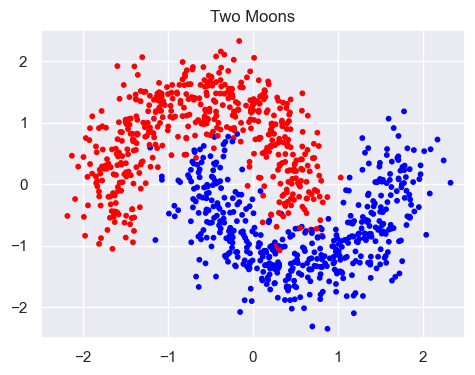

In [40]:
# moon-circle dataset
features_moon, label_moon = datasets.make_moons(n_samples=1000, noise=0.2, random_state=42)
scaler = StandardScaler()
#fit transform data
features_moon = scaler.fit_transform(features_moon, label_moon)
label_moon = label_moon.astype('int')
# plotting dataset
cm_bright = ListedColormap(["#FF0000", "#0000FF"])

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(features_moon[:, 0], features_moon[:, 1], c =label_moon, cmap = cm_bright, s=10)

# create a meshgrid
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 100), np.linspace(-2, 1.5, 100))
plt.xlim([-2.5,2.5])
plt.ylim([-2.5,2.5])


plt.title("Two Moons")
plt.rcParams['font.size']=15
plt.tight_layout()
plt.savefig("moon_appendix" + '.png',format='png', dpi=300)

In [41]:
metric = "rbf"
model = "Logistic_Regression"
wit_val, wit_test, y_wit, y_test, yhat_wit, yhat_test= lightweight_calibration_with_witness(features_moon, label_moon, baseline_model=model, witness_metric = metric)

Logistic_Regression Baseline Model Performance
Accuracy: 86.00
AUC: 94.67
Optimal Gamma: 8.0


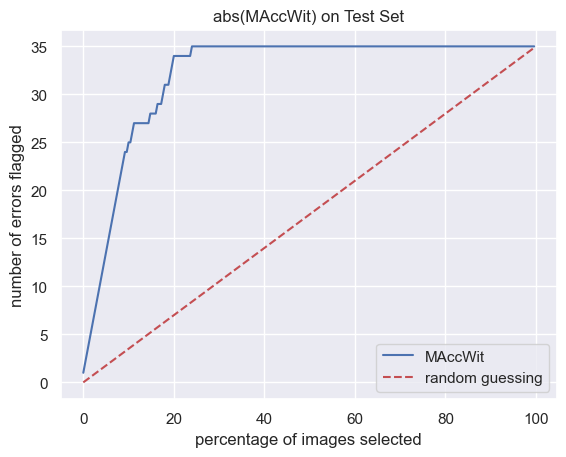

In [42]:
plot_percentage_error_over_sample(wit_test, y_test, yhat_test, wit_take_abs=True, is_test_set=True)

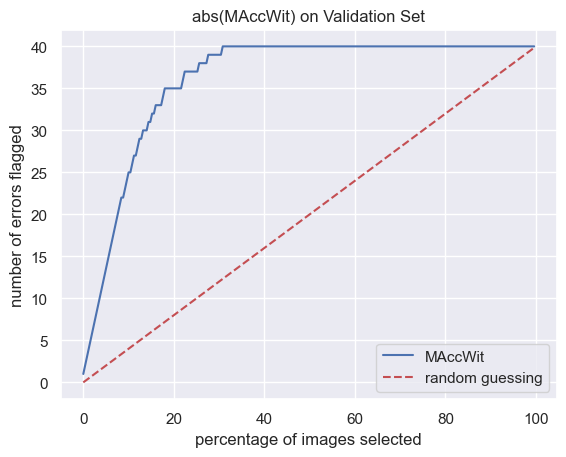

In [43]:
plot_percentage_error_over_sample(wit_val, y_wit, yhat_wit, wit_take_abs=True, is_test_set=False)

wit_val: 1.372,2.253


(array([171.,  29.,   5.,   8.,   8.,   9.,   7.,   4.,   5.,   4.]),
 array([1.08161949e-09, 9.47169501e-01, 1.89433900e+00, 2.84150850e+00,
        3.78867800e+00, 4.73584750e+00, 5.68301700e+00, 6.63018650e+00,
        7.57735600e+00, 8.52452550e+00, 9.47169500e+00]),
 <BarContainer object of 10 artists>)

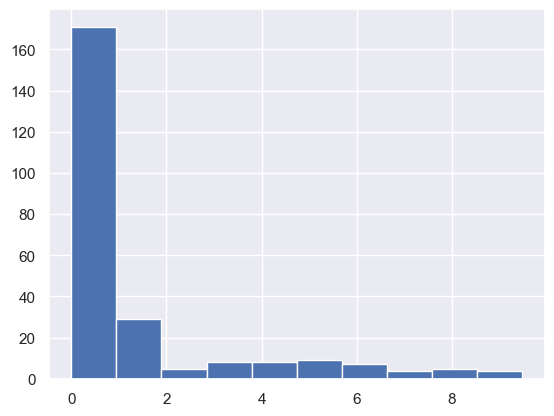

In [44]:
print(f"wit_val: {np.mean(wit_val):.3f},{np.std(wit_val):.3f}")
plt.hist(wit_val)

wit_test: 1.275,2.216


(array([180.,  21.,  11.,   8.,   6.,   5.,   9.,   2.,   3.,   5.]),
 array([1.88316979e-07, 9.82704544e-01, 1.96540890e+00, 2.94811326e+00,
        3.93081761e+00, 4.91352197e+00, 5.89622632e+00, 6.87893068e+00,
        7.86163503e+00, 8.84433939e+00, 9.82704375e+00]),
 <BarContainer object of 10 artists>)

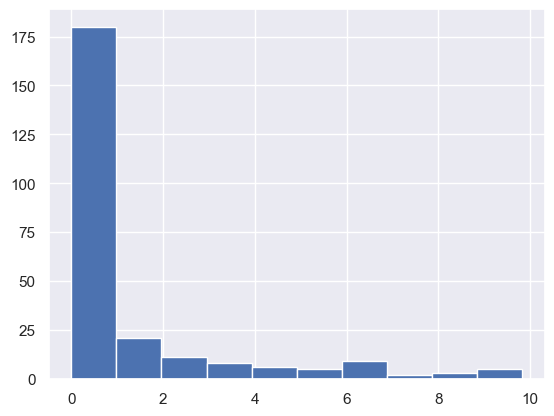

In [45]:
print(f"wit_test: {np.mean(wit_test):.3f},{np.std(wit_test):.3f}")
plt.hist(wit_test)

### Folktables

In [111]:
# Health Public Coverage Task WI
data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
data = data_source.get_data(states= ["WI"], download=True)
features, labels, _ = ACSPublicCoverage.df_to_numpy(data)
prefix = "Health_WI"

model="Logistic_Regression"
metric = 'rbf'
seed = 42

In [112]:
wit_val, wit_test, y_wit, y_test, yhat_wit, yhat_test, yhat_proba_wit, yhat_proba_test= lightweight_calibration_with_witness(features, labels, baseline_model=model, witness_metric = metric)

Logistic_Regression Baseline Model Performance
Accuracy: 78.47
AUC: 76.32
Dimensionality reduction using PCA
Optimal Gamma: 7.5


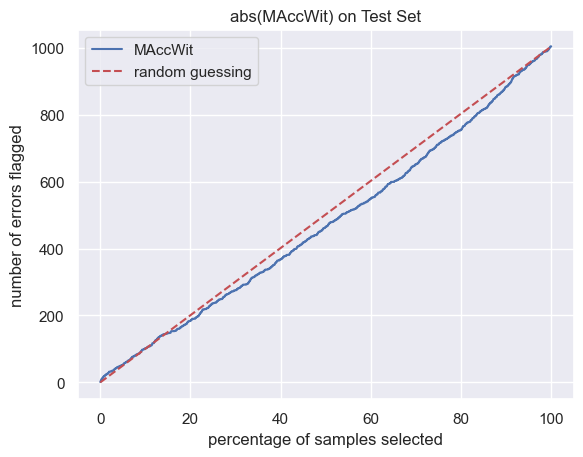

In [113]:
plot_percentage_error_over_sample(wit_test, y_test, yhat_test, wit_take_abs=True, is_test_set=True)

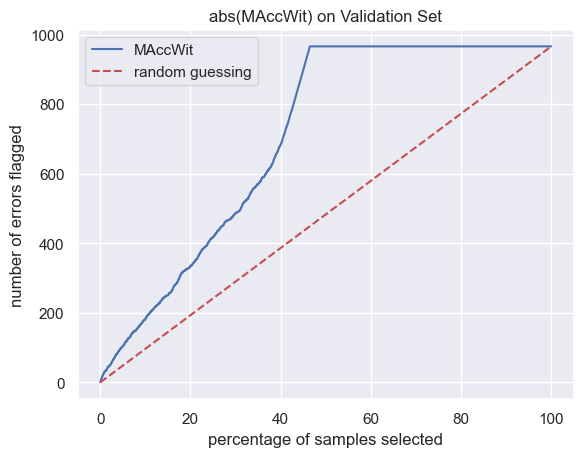

In [117]:
plot_percentage_error_over_sample(wit_val, y_wit, yhat_wit, wit_take_abs=True, is_test_set=False)

wit_val: 1.051,1.156


(array([2210., 1291.,  567.,  270.,  145.,   72.,   68.,   18.,   16.,
           6.]),
 array([2.68232689e-102, 7.43787642e-001, 1.48757528e+000, 2.23136293e+000,
        2.97515057e+000, 3.71893821e+000, 4.46272585e+000, 5.20651349e+000,
        5.95030114e+000, 6.69408878e+000, 7.43787642e+000]),
 <BarContainer object of 10 artists>)

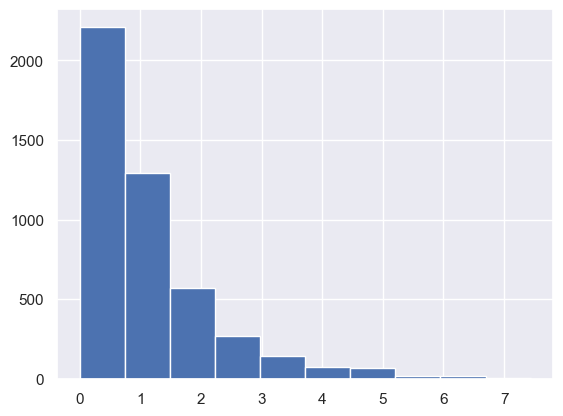

In [98]:
print(f"wit_val: {np.mean(wit_val):.3f},{np.std(wit_val):.3f}")
plt.hist(wit_val)

wit_test: 0.847,1.058


(array([2.761e+03, 9.700e+02, 4.860e+02, 2.040e+02, 1.160e+02, 5.900e+01,
        4.400e+01, 1.600e+01, 7.000e+00, 1.000e+00]),
 array([9.43572923e-114, 7.43787642e-001, 1.48757528e+000, 2.23136293e+000,
        2.97515057e+000, 3.71893821e+000, 4.46272585e+000, 5.20651349e+000,
        5.95030114e+000, 6.69408878e+000, 7.43787642e+000]),
 <BarContainer object of 10 artists>)

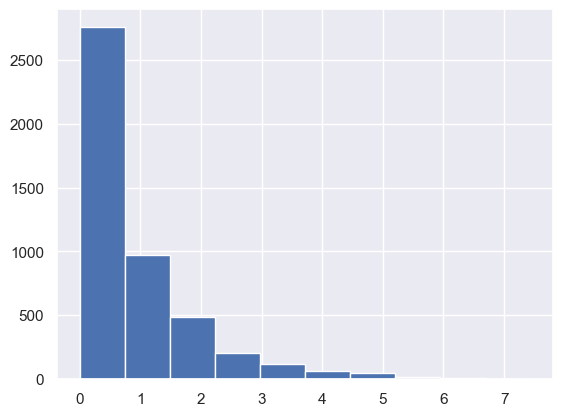

In [99]:
print(f"wit_test: {np.mean(wit_test):.3f},{np.std(wit_test):.3f}")
plt.hist(wit_test)

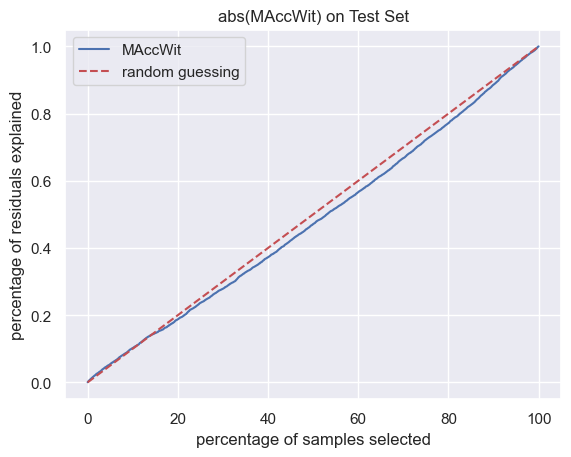

In [115]:
plot_multiaccuracy_over_sample(wit_test, y_test, yhat_proba_test, wit_take_abs = True, is_test_set = True, show_imgs=False)

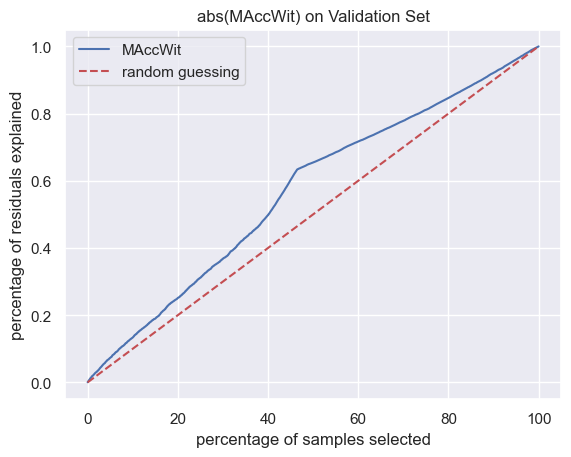

In [116]:
plot_multiaccuracy_over_sample(wit_val, y_wit, yhat_proba_wit, wit_take_abs = True, is_test_set = False, show_imgs=False)

### with PCA and specified Gamma

In [89]:

def testing_lightweight_calibration_with_witness(features,label, baseline_model, witness_metric, gamma):
  scaler = StandardScaler()
  #fit transform data
  features = scaler.fit_transform(features, label)
  label = label.astype('int')
  # label = np.intc(label)

  X_train_val, X_test, y_train_val, y_test = train_test_split(
      features, label, test_size=0.5, random_state=0)

  X_train, X_val, y_train, y_val = train_test_split(
      X_train_val, y_train_val, test_size=0.5, random_state=0)

  X_wit, X_test, y_wit, y_test = train_test_split(
      X_test, y_test, test_size=0.5, random_state=0)
  
  # baseline classifier
  if baseline_model == "Logistic_Regression":
      model = LogisticRegression()
  elif baseline_model == "Decision_Tree":
      model = DecisionTreeClassifier(max_depth = 1)
  elif baseline_model == "Random_Forest":
      model = RandomForestClassifier(max_depth=2, random_state=0)
  elif baseline_model == "Kernel_SVM":
      model = SVC(gamma="auto", probability = True)
  elif baseline_model == "Naive_Bayes":
      model = GaussianNB()
  elif baseline_model == "NN":
      model = MLPClassifier(random_state=1, max_iter=300)
  else:
    return "Baseline not supported"
  #model = make_pipeline(StandardScaler(), LogisticRegression())
  model.fit(X_train, y_train)

  yhat = model.predict(X_test)
  if baseline_model == "Logistic_Regression":
    yhat_prob = model.predict_proba(X_test)
    # choose the probability of the positive class
    yhat_prob = yhat_prob[:, 1]
  else:
    yhat_prob = model.predict(X_test)

  # evaluate the accuracy of the model
  accuracy = accuracy_score(y_test, yhat>0.5)
  # , multi_class = 'ovr'
  auc = roc_auc_score(y_test, yhat_prob)
  print(f'{baseline_model} Baseline Model Performance')
  print('Accuracy: %.2f' % (accuracy*100))
  print('AUC: %.2f' % (auc*100))

  if baseline_model == "Logistic_Regression":
    yhat_proba_test = model.predict_proba(X_test)[:, 1]
    yhat_proba_wit = model.predict_proba(X_wit)[:, 1]
    yhat_proba_val = model.predict_proba(X_val)[:, 1]
  else:
    yhat_proba_test = model.predict(X_test)
    yhat_proba_wit = model.predict(X_wit)
    yhat_proba_val = model.predict(X_val)


  error_test = y_test - yhat_proba_test
  error_wit = y_wit - yhat_proba_wit
  error_val = y_val - yhat_proba_val


  yhat_wit = (yhat_proba_wit>=0.5).astype(int)
  yhat_test = (yhat_proba_test>=0.5).astype(int)
  # search for optimal rbf kernel param using validation set
  # witness_metric = 'rbf'

  # dimensionality reduction for dim>5
  if X_wit.shape[1] > 5:
    print('Dimensionality reduction using PCA')
    pca = PCA(n_components=10)
    X_wit = pca.fit_transform(X_wit)
    X_test = pca.transform(X_test)
    X_val = pca.transform(X_val)
    
  #gopt = grid_search_params(witness_metric, X_val, error_val)

  # define witness on train and validation
  wit = MAccWitness(gamma=gamma, metric=witness_metric)

  wit_model = make_pipeline(StandardScaler(), wit)
  # fit 0-1 error to witness function
  error_wit = (y_wit != yhat_wit).astype(int)
  wit_model.fit(X_wit, error_wit)

  wit_val = wit_model.predict(X_wit)
  wit_test = wit_model.predict(X_test)


  return wit_val, wit_test, y_wit, y_test, yhat_wit, yhat_test

In [90]:
wit_vals = []
wit_tests = []
y_wits = []
y_tests = []
yhat_wits = []
yhat_tests = []
gammas = [10]
for gamma in gammas:
    wit_val, wit_test, y_wit, y_test, yhat_wit, yhat_test = testing_lightweight_calibration_with_witness(features, labels, baseline_model=model, witness_metric = metric, gamma = gamma)
    wit_vals.append(wit_val)
    wit_tests.append(wit_test)
    y_wits.append(y_wit)
    y_tests.append(y_test)
    yhat_wits.append(yhat_wit)
    yhat_tests.append(yhat_test)

Logistic_Regression Baseline Model Performance
Accuracy: 78.47
AUC: 76.32
Dimensionality reduction using PCA


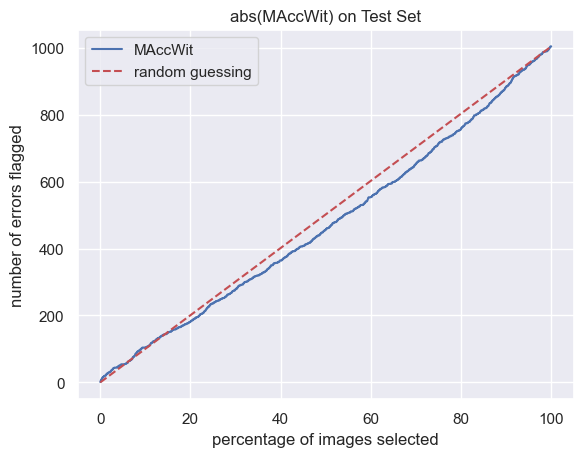

In [91]:
for i in range(len(gammas)):
    plot_percentage_error_over_sample(wit_tests[i], y_tests[i], yhat_tests[i], wit_take_abs=True, is_test_set=True)

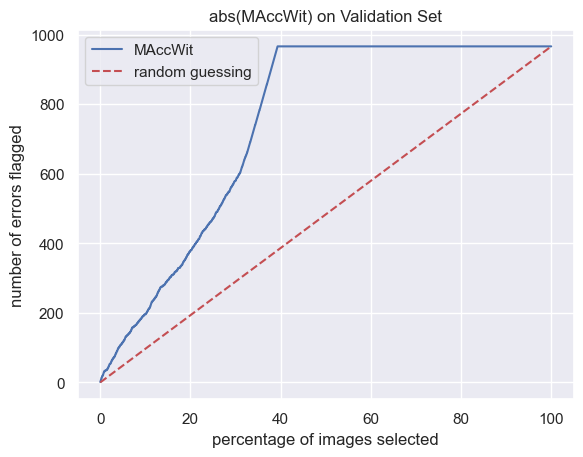

In [92]:
for i in range(len(gammas)):
    plot_percentage_error_over_sample(wit_vals[i], y_wits[i], yhat_wits[i], wit_take_abs=True, is_test_set=False)